In [ ]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dt = 0.01
noise_levels = np.logspace(-3, 0, 10).tolist()
t_spans = sorted([(0, 3*i) for i in range(1, 9 + 1)], reverse=True)

t_span_test = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    'np_seed': 0, 'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_spans,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config)

 78%|███████▊  | 7/9 [00:08<00:02,  1.18s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:131: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 9/9 [00:17<00:00,  1.91s/it]


step 2 of 10


 67%|██████▋   | 6/9 [00:07<00:03,  1.09s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(
100%|██████████| 9/9 [00:15<00:00,  1.77s/it]


step 3 of 10


100%|██████████| 9/9 [00:13<00:00,  1.45s/it]


...

100%|██████████| 9/9 [00:18<00:00,  2.06s/it]


step 9 of 10


100%|██████████| 9/9 [00:18<00:00,  2.05s/it]


step 10 of 10


 11%|█         | 1/9 [00:02<00:20,  2.57s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 9/9 [00:19<00:00,  2.22s/it]


rows are noise_level. there are 10 rows.
columns are t_span_train. there are 9 columns.


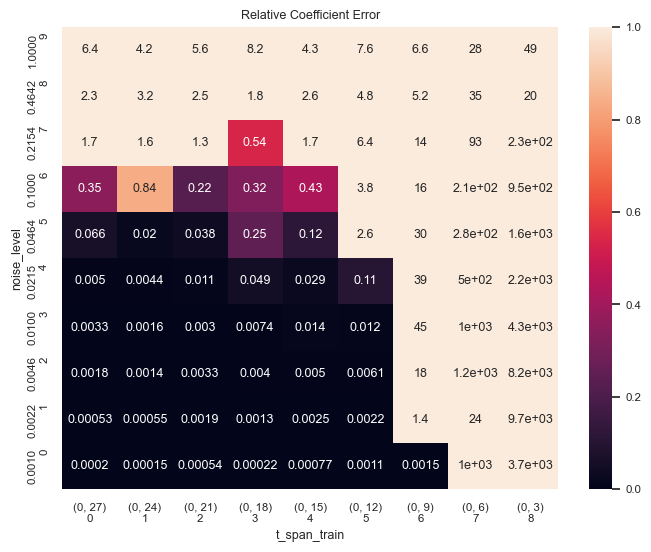

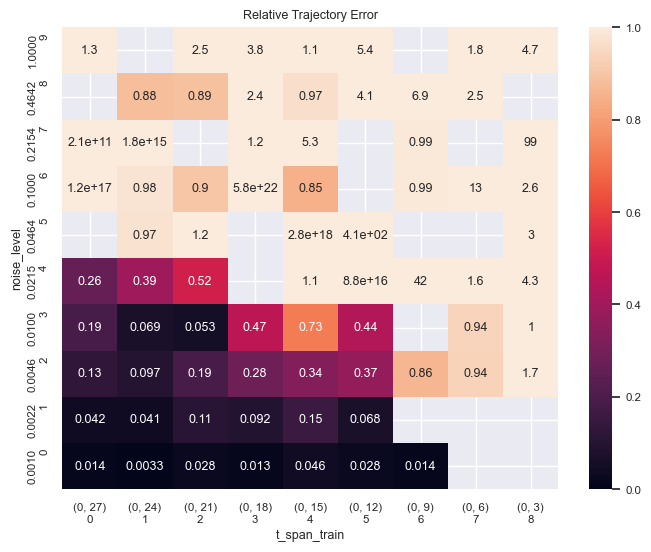

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 1.09175 x0 + -0.40061 x0 x1 
x1' = + -0.40291 x1 + 0.11139 x0 x1 


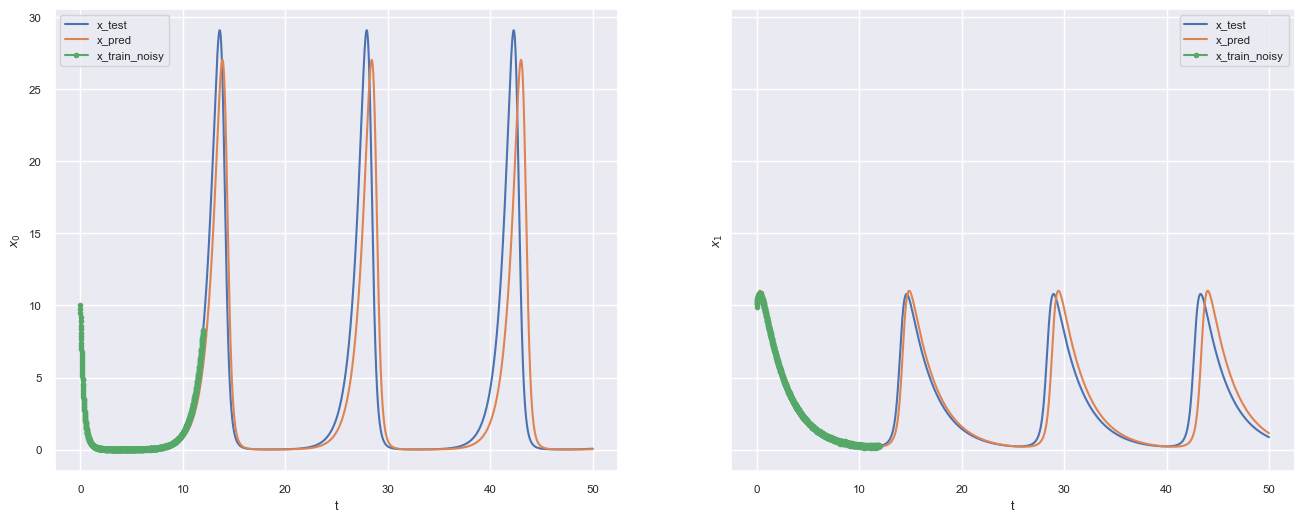

In [4]:
display_single_result(experiment_config, results, 5, 3, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])